In [1]:
!git clone https://github.com/sl2902/triagegeist.git

Cloning into 'triagegeist'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 53 (delta 16), reused 51 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 160.91 KiB | 2.20 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
import sys
sys.path.append('/kaggle/working/triagegeist/src')

In [9]:
import config
from model_training import run_model_pipeline
from feature_importance_analysis import find_important_and_unimportant_features
from bias_importance_demographics import bias_analysis
from model_predictions import run_prediction_pipeline
from charts import draw_charts
from statistical_testing import perform_statistical_testing

The source of traigegeist dataset on Kaggle may change. For example, it could either be

1) /kaggle/input/triagegist
2) /kaggle/input/competitions/triagegeist
3) /kaggle/input/datasets/username/triagegeist

# Baseline model training

In [4]:
filepath = '/kaggle/input/competitions/triagegeist'
X, y, oof_preds, cat_cols = run_model_pipeline(filepath=filepath)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.320046
Early stopping, best iteration is:
[132]	valid_0's multi_logloss: 0.317849
Fold 1 — QWK: 0.9310 | Weighted F1: 0.8571
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.323367
Early stopping, best iteration is:
[128]	valid_0's multi_logloss: 0.320967
Fold 2 — QWK: 0.9297 | Weighted F1: 0.8543
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.318924
Early stopping, best iteration is:
[140]	valid_0's multi_logloss: 0.316077
Fold 3 — QWK: 0.9308 | Weighted F1: 0.8585
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.324232
Early stopping, best iteration is:
[145]	valid_0's multi_logloss: 0.321582
Fold 4 — QWK: 0.9325 | Weighted F1: 0.8592
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.323898
Early stopping, best it

# Feature importance

Top 20 and bottom 10

In [5]:
find_important_and_unimportant_features(X, y, cat_cols)

Top 20 features by gain:
                feature  importance_split  importance_gain
            news2_score              3116    465451.413969
             pain_score              5335    296248.198881
              gcs_total              1563    224480.285226
                   spo2              9069    137179.913311
          temperature_c              7144     90288.618873
       respiratory_rate             10736     85802.092649
           gcs_abnormal               290     63237.595592
num_prior_ed_visits_12m              3745     58093.069024
        triage_nurse_id             10370     55952.396185
 mean_arterial_pressure              7643     51497.562006
             heart_rate              8231     41112.887950
   mental_status_triage              1161     35533.769681
            shock_index              6973     28893.253588
            systolic_bp              6369     24477.259397
           diastolic_bp              7213     24261.272283
         pulse_pressure        

# Bias analysis of demographic dimensions

In [8]:
df = bias_analysis(X, y, oof_preds)

=== NURSE-LEVEL BIAS ===
                    n  mean_true_esi  mean_pred_esi  undertriage_rate     qwk  esi_bias
triage_nurse_id                                                                        
NURSE-0022       1578         3.2700         3.2738            0.0672  0.9382    0.0038
NURSE-0032       1621         3.2838         3.2881            0.0808  0.9250    0.0043
NURSE-0014       1587         3.2917         3.2905            0.0580  0.9469   -0.0012
NURSE-0019       1656         3.2929         3.3116            0.0821  0.9337    0.0187
NURSE-0011       1603         3.2932         3.2838            0.0699  0.9284   -0.0094
NURSE-0008       1543         3.2936         3.2942            0.0668  0.9371    0.0006
NURSE-0036       1551         3.2966         3.3095            0.0806  0.9315    0.0129
NURSE-0043       1592         3.2971         3.2977            0.0660  0.9290    0.0006
NURSE-0031       1649         3.3008         3.2971            0.0685  0.9264   -0.0037
NURSE-0

# Model prediction

In [7]:
run_prediction_pipeline(filepath)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[134]	valid_0's multi_logloss: 0.319407
Fold 1 done
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's multi_logloss: 0.32163
Fold 2 done
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[148]	valid_0's multi_logloss: 0.316426
Fold 3 done
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[133]	valid_0's multi_logloss: 0.32229
Fold 4 done
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[132]	valid_0's multi_logloss: 0.324072
Fold 5 done

Prediction distribution:
1     737
2    3390
3    7252
4    5820
5    2801
Name: count, dtype: int64

Sample submission:
     patient_id  triage_acuity
0  TG-FZUFCRZS3              2
1  TG-SSCOXTYI1              3
2  TG-JY74ZR35D              2
3  TG-JDKD5G62X 

# Charts

How language at ESI 3 impacts Triage

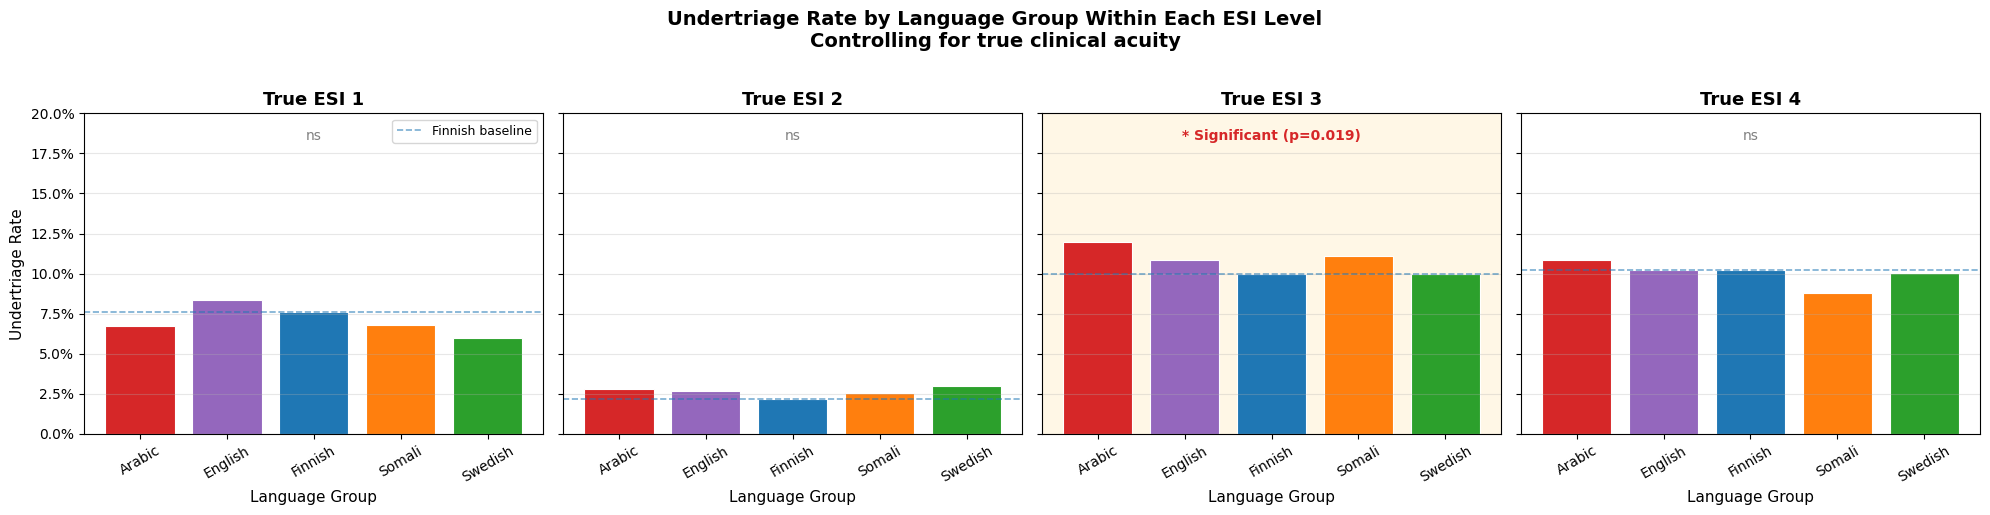

Chart 1 saved


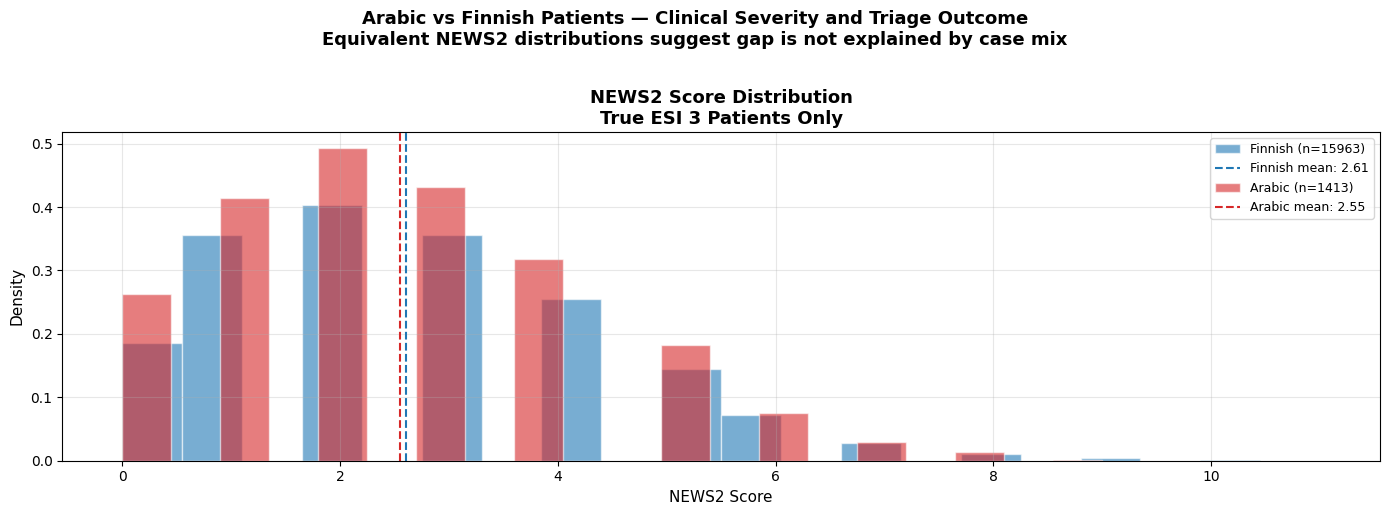

Chart 2 saved


In [10]:
draw_charts(df)

# Statistical Testing

ChiSquare Test<br>
Mann-Whitney U

In [11]:
perform_statistical_testing(df)

=== NEWS2 Clinical Severity Comparison (ESI 3 patients) ===
Arabic  — n=1413, mean=2.550, median=2.000
Finnish — n=15963, mean=2.606, median=2.000
Mann-Whitney U statistic: 11115038.0
P-value: 0.3602
Interpretation: No significant difference in clinical severity

=== Undertriage Rate Comparison: Arabic vs Finnish by ESI Level ===
 ESI Level  Arabic n  Finnish n Arabic undertriage % Finnish undertriage %  Chi2  p-value Significant
         1       163       1773                 6.7%                  7.6% 0.060   0.8060          No
         2       675       7379                 2.8%                  2.2% 0.772   0.3797          No
         3      1413      15963                12.0%                 10.0% 5.526   0.0187         Yes
         4      1103      12688                10.9%                 10.2% 0.418   0.5181          No
